In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


df = pd.read_csv("/content/heart_disease.csv")
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Dataset Shape: (920, 16)

Column Names: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data Types:
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing Values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [3]:
df_cleaned = df.drop(columns=['id', 'dataset'])

#Drop columns with >50% missing data
missing_percent = df_cleaned.isnull().mean() * 100
df_cleaned = df_cleaned.drop(columns=missing_percent[missing_percent > 50].index)

#Fill remaining missing values
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
    else:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

print("\nMissing Values After Cleaning:\n", df_cleaned.isnull().sum())



Missing Values After Cleaning:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64


<ipython-input-3-e464c50036c8>:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])


In [4]:
df_cleaned.to_csv("/content/cleaned_heart_data.csv", index=False)
print("✅ Cleaned data saved as 'cleaned_heart_data.csv'")


✅ Cleaned data saved as 'cleaned_heart_data.csv'


<ipython-input-6-8cd72a4fe060>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='num', palette='Set2')


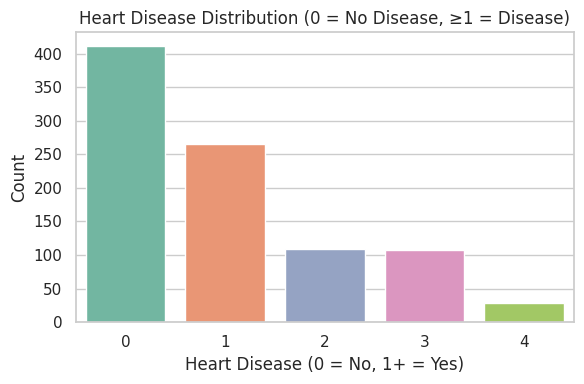

In [6]:
# Plot 1: Count of Heart Disease (Target Variable)
plt.figure(figsize=(6,4))
sns.countplot(data=df_cleaned, x='num', palette='Set2')
plt.title("Heart Disease Distribution (0 = No Disease, ≥1 = Disease)")
plt.xlabel("Heart Disease (0 = No, 1+ = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

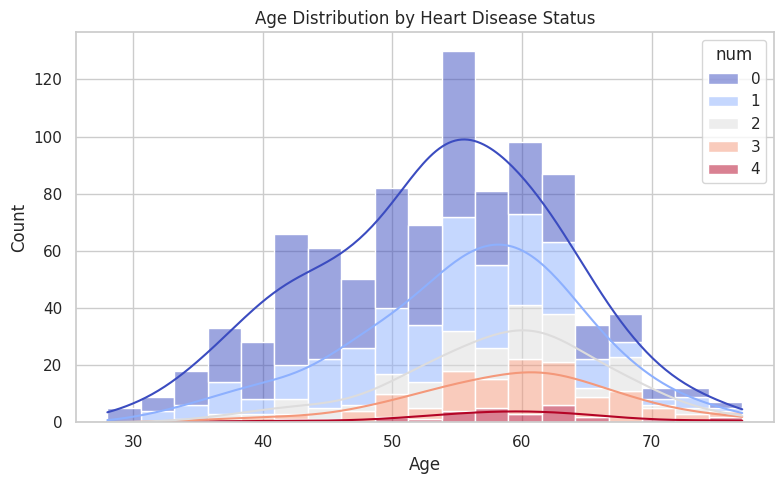

In [7]:
# Plot 2: Age Distribution by Heart Disease Status
plt.figure(figsize=(8,5))
sns.histplot(data=df_cleaned, x='age', hue='num', multiple='stack', kde=True, palette='coolwarm')
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


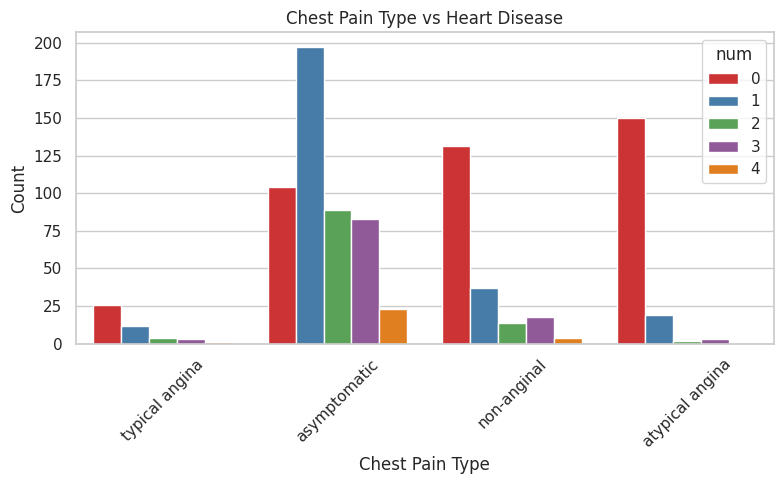

In [8]:
# Plot 3: Chest Pain Type vs Heart Disease
plt.figure(figsize=(8,5))
sns.countplot(data=df_cleaned, x='cp', hue='num', palette='Set1')
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
